In [11]:
# ==========================================
# CELL 1: SETUP AND DATA LOADING
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import numpy as np

# Set publication-quality plotting style
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'figure.autolayout': True, 
    'axes.titlesize': 14, 
    'axes.labelsize': 12,
    'font.size': 11
})

# Your raw CSV data
csv_data = """Dataset,Miner,Fit_Full,Fit_3Fold,PM4Py_Gen,1G_Shadow,3G_Shadow,6G_Shadow,KFold_Time_s,1G_Time_s,3G_Time_s,6G_Time_s
BPI_2017,Alpha Miner,0.3826,0.3946,0.9824,0.3991,0.3986,0.3886,28.6,4.2,7.0,10.2
BPI_2017,Alpha+ Miner,0.8818,0.8786,0.9828,0.6011,0.6949,0.7538,40.2,4.2,6.4,10.6
BPI_2017,Heuristics (Default),0.9508,0.9505,0.917,0.9288,0.8672,0.8852,70.4,7.3,11.2,14.1
BPI_2017,Heuristics (Strict),0.9528,0.9521,0.9463,0.9391,0.8795,0.8951,66.0,6.8,10.3,14.0
BPI_2017,Inductive (Strict),1.0,1.0,0.9485,0.9658,0.9872,0.9952,192.7,7.9,9.4,12.6
BPI_2017,Inductive (Infrequent),0.9786,0.9802,0.9473,0.9434,0.9329,0.9497,154.8,6.9,10.5,13.3
BPI_2017,Flower Model (Max),1.0,1.0,0.9824,1.0,1.0,1.0,27.2,4.1,6.2,9.5
BPI_2019,Alpha Miner,0.339,0.337,0.9112,0.3402,0.3539,0.3629,23.1,4.4,6.1,8.1
BPI_2019,Alpha+ Miner,0.4432,0.4409,0.9147,0.4022,0.4549,0.4558,55.6,4.7,6.5,9.5
BPI_2019,Heuristics (Default),0.8365,0.8675,0.7689,0.8335,0.8119,0.8163,90.7,6.0,9.8,11.3
BPI_2019,Heuristics (Strict),0.9154,0.9336,0.8707,0.8863,0.8495,0.8553,77.9,6.2,9.5,11.2
BPI_2019,Inductive (Strict),1.0,0.9973,0.9182,0.9996,0.9983,0.9979,291.0,5.4,7.8,10.9
BPI_2019,Inductive (Infrequent),0.993,0.9948,0.8923,0.9899,0.9683,0.9726,132.7,4.8,6.7,8.7
BPI_2019,Flower Model (Max),1.0,1.0,0.9112,1.0,1.0,1.0,22.8,4.5,6.2,8.4
Sepsis,Alpha Miner,0.2659,0.2522,0.9132,0.2673,0.2854,0.2897,0.5,0.8,0.9,0.9
Sepsis,Alpha+ Miner,0.8264,0.8316,0.9189,0.6044,0.5503,0.6235,0.7,1.0,1.1,1.1
Sepsis,Heuristics (Default),0.8968,0.9023,0.8415,0.875,0.8215,0.8379,1.2,1.9,2.2,2.0
Sepsis,Heuristics (Strict),0.9332,0.9302,0.9004,0.8931,0.8445,0.8583,1.2,1.8,1.9,2.0
Sepsis,Inductive (Strict),1.0,0.9999,0.9025,0.9758,0.9414,0.9579,1.7,1.6,1.7,1.7
Sepsis,Inductive (Infrequent),0.9872,0.9858,0.8799,0.9108,0.8884,0.917,1.0,1.3,1.5,1.4
Sepsis,Flower Model (Max),1.0,1.0,0.9132,1.0,1.0,1.0,0.5,0.8,0.8,0.9
Hospital_Billing,Alpha Miner,0.6798,0.6801,0.9126,0.741,0.7644,0.7658,2.7,1.3,1.5,1.8
Hospital_Billing,Alpha+ Miner,0.3228,0.3511,0.9188,0.341,0.4065,0.3941,11.8,1.3,1.6,1.9
Hospital_Billing,Heuristics (Default),0.9173,0.9173,0.7433,0.9216,0.8059,0.8219,6.2,1.6,2.0,2.2
Hospital_Billing,Heuristics (Strict),0.9194,0.9195,0.9026,0.9242,0.81,0.8162,5.0,1.3,1.9,2.4
Hospital_Billing,Inductive (Strict),1.0,1.0,0.9349,1.0,0.9997,0.9997,4.3,1.4,1.9,2.2
Hospital_Billing,Inductive (Infrequent),0.9899,0.9918,0.9327,0.9852,0.9481,0.9492,4.1,1.3,1.8,2.1
Hospital_Billing,Flower Model (Max),1.0,1.0,0.9126,1.0,1.0,1.0,2.5,1.6,1.6,1.9
Road_Traffic_Fine,Alpha Miner,0.6378,0.6384,0.9856,0.6701,0.7132,0.7151,3.0,1.4,1.6,1.8
Road_Traffic_Fine,Alpha+ Miner,0.3926,0.4021,0.9807,0.3769,0.4081,0.4051,13.2,1.5,1.7,1.9
Road_Traffic_Fine,Heuristics (Default),0.9284,0.9283,0.9304,0.912,0.8165,0.8166,5.0,1.5,1.6,1.9
Road_Traffic_Fine,Heuristics (Strict),0.9352,0.934,0.8899,0.9281,0.8185,0.8262,4.9,1.5,1.6,1.8
Road_Traffic_Fine,Inductive (Strict),1.0,1.0,0.9753,0.9976,0.9914,0.9925,2.8,1.5,1.6,1.9
Road_Traffic_Fine,Inductive (Infrequent),0.9995,0.9944,0.9483,0.9987,0.9958,0.9964,2.7,1.5,1.6,1.8
Road_Traffic_Fine,Flower Model (Max),1.0,1.0,0.9856,1.0,1.0,1.0,2.1,1.5,1.6,1.8"""

df = pd.read_csv(io.StringIO(csv_data))
display(df.head())

,Dataset,Miner,Fit_Full,Fit_3Fold,PM4Py_Gen,1G_Shadow,3G_Shadow,6G_Shadow,KFold_Time_s,1G_Time_s,3G_Time_s,6G_Time_s
0,BPI_2017,Alpha Miner,0.3826,0.3946,0.9824,0.3991,0.3986,0.3886,28.6,4.2,7.0,10.2
1,BPI_2017,Alpha+ Miner,0.8818,0.8786,0.9828,0.6011,0.6949,0.7538,40.2,4.2,6.4,10.6
2,BPI_2017,Heuristics (Default),0.9508,0.9505,0.9170,0.9288,0.8672,0.8852,70.4,7.3,11.2,14.1
3,BPI_2017,Heuristics (Strict),0.9528,0.9521,0.9463,0.9391,0.8795,0.8951,66.0,6.8,10.3,14.0
4,BPI_2017,Inductive (Strict),1.0000,1.0000,0.9485,0.9658,0.9872,0.9952,192.7,7.9,9.4,12.6


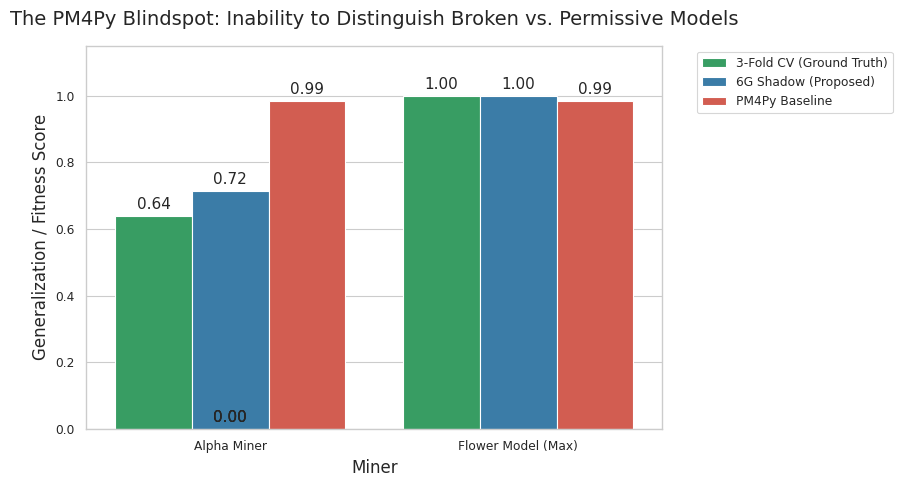

In [3]:
# ==========================================
# CELL 2: PM4Py BLINDSPOT (Road Traffic Fine)
# ==========================================
df_road = df[df['Dataset'] == 'Road_Traffic_Fine'].copy()

# Select only Alpha Miner and Flower Model to prove the boundary failure
df_blind = df_road[df_road['Miner'].isin(['Alpha Miner', 'Flower Model (Max)'])]

# Melt for Seaborn
df_melted_blind = df_blind.melt(
    id_vars=['Miner'], 
    value_vars=['Fit_3Fold', '6G_Shadow', 'PM4Py_Gen'], 
    var_name='Metric', 
    value_name='Score'
)

# Rename for nicer plot labels
metric_names = {
    'Fit_3Fold': '3-Fold CV (Ground Truth)', 
    '6G_Shadow': '6G Shadow (Proposed)', 
    'PM4Py_Gen': 'PM4Py Baseline'
}
df_melted_blind['Metric'] = df_melted_blind['Metric'].map(metric_names)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=df_melted_blind, x='Miner', y='Score', hue='Metric', palette=['#27AE60', '#2980B9', '#E74C3C'])

plt.title('The PM4Py Blindspot: Inability to Distinguish Broken vs. Permissive Models', pad=15)
plt.ylabel('Generalization / Fitness Score')
plt.ylim(0, 1.15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', xytext=(0, 5), textcoords='offset points')

plt.show()

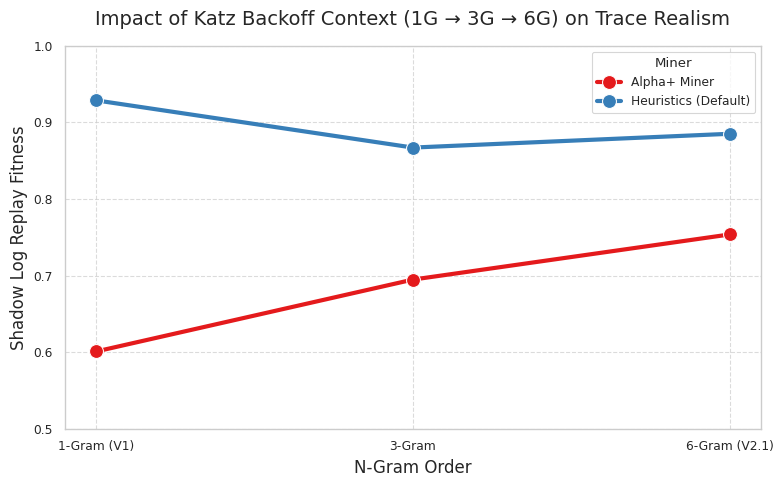

In [4]:
# ==========================================
# CELL 3: CONTEXT EVOLUTION (Katz Backoff)
# ==========================================
df_bpi = df[df['Dataset'] == 'BPI_2017'].copy()

# Focus on Alpha+ and Heuristics to show the effect clearly
df_evo = df_bpi[df_bpi['Miner'].isin(['Alpha+ Miner', 'Heuristics (Default)'])]

df_melted_evo = df_evo.melt(
    id_vars=['Miner'], 
    value_vars=['1G_Shadow', '3G_Shadow', '6G_Shadow'], 
    var_name='N-Gram Order', 
    value_name='Score'
)

plt.figure(figsize=(8, 5))
ax = sns.lineplot(data=df_melted_evo, x='N-Gram Order', y='Score', hue='Miner', 
                  marker='o', linewidth=3, markersize=10, palette='Set1')

plt.title('Impact of Katz Backoff Context (1G → 3G → 6G) on Trace Realism', pad=15)
plt.ylabel('Shadow Log Replay Fitness')
plt.ylim(0.5, 1.0)

# Add custom labels
plt.xticks([0, 1, 2], ['1-Gram (V1)', '3-Gram', '6-Gram (V2.1)'])
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

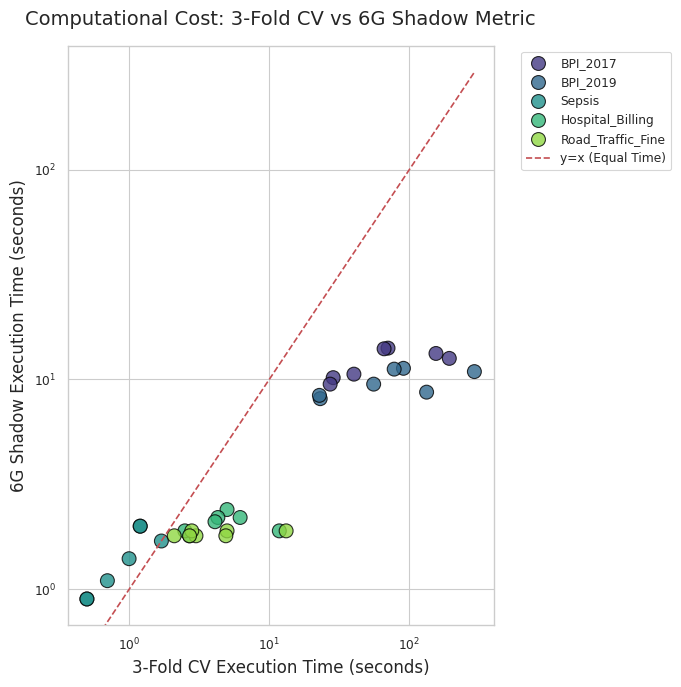

In [5]:
# ==========================================
# CELL 4: RUNTIME VS GROUND TRUTH (SCATTER)
# ==========================================
plt.figure(figsize=(7, 7))

# Plot the runtime comparison
sns.scatterplot(data=df, x='KFold_Time_s', y='6G_Time_s', hue='Dataset', 
                s=100, palette='viridis', edgecolor='black', alpha=0.8)

# Draw the y=x reference line (where 6G time = KFold time)
max_val = max(df['KFold_Time_s'].max(), df['6G_Time_s'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='y=x (Equal Time)')

plt.title('Computational Cost: 3-Fold CV vs 6G Shadow Metric', pad=15)
plt.xlabel('3-Fold CV Execution Time (seconds)')
plt.ylabel('6G Shadow Execution Time (seconds)')

# Use log scale to handle the massive 291s outlier clearly
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

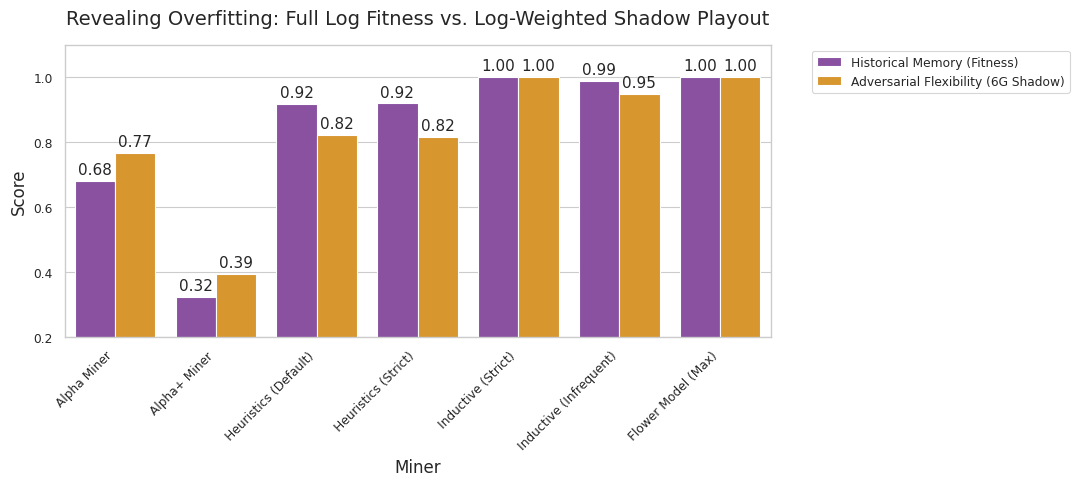

In [6]:
# ==========================================
# CELL 5: FITNESS VS. ADVERSARIAL GENERALIZATION
# ==========================================
df_hosp = df[df['Dataset'] == 'Hospital_Billing'].copy()

df_melted_adv = df_hosp.melt(
    id_vars=['Miner'], 
    value_vars=['Fit_Full', '6G_Shadow'], 
    var_name='Metric', 
    value_name='Score'
)

# Rename
metric_names_adv = {'Fit_Full': 'Historical Memory (Fitness)', '6G_Shadow': 'Adversarial Flexibility (6G Shadow)'}
df_melted_adv['Metric'] = df_melted_adv['Metric'].map(metric_names_adv)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=df_melted_adv, x='Miner', y='Score', hue='Metric', palette=['#8E44AD', '#F39C12'])

plt.title('Revealing Overfitting: Full Log Fitness vs. Log-Weighted Shadow Playout', pad=15)
plt.ylabel('Score')
plt.ylim(0.2, 1.1)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', xytext=(0, 5), textcoords='offset points')

plt.show()

/tmp/ipykernel_5308/4193318207.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_corr, x='Metric', y='Spearman_rho', capsize=.1, errorbar='sd', palette=['#E74C3C', '#95A5A6', '#2980B9'])


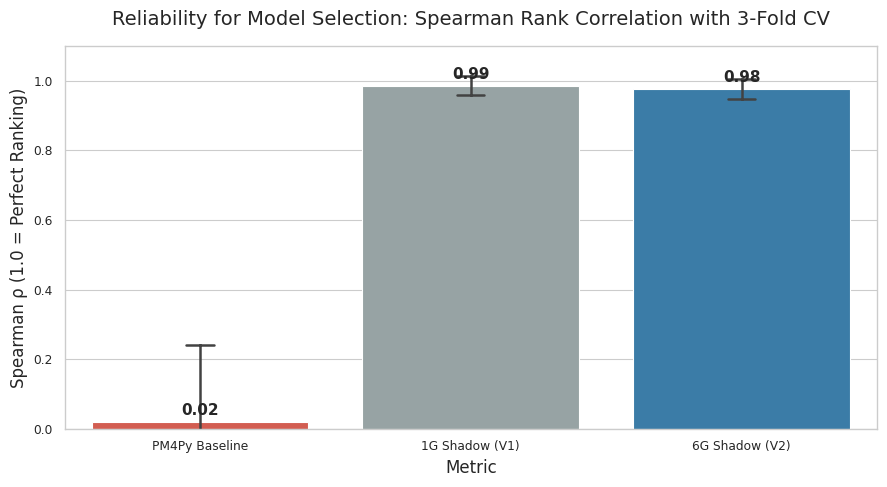

In [7]:
# ==========================================
# CELL 6: RANK CORRELATION (SPEARMAN)
# ==========================================
from scipy.stats import spearmanr

# FIXED: Changed 'PM4Py_Baseline' to 'PM4Py_Gen'
metrics = ['PM4Py_Gen', '1G_Shadow', '6G_Shadow']
correlations = []

# Calculate Spearman rank correlation for each dataset individually
for dataset in df['Dataset'].unique():
    df_sub = df[df['Dataset'] == dataset]
    for metric in metrics:
        # How well does the metric's ranking match the 3-Fold CV ranking?
        corr, _ = spearmanr(df_sub['Fit_3Fold'], df_sub[metric])
        correlations.append({'Dataset': dataset, 'Metric': metric, 'Spearman_rho': corr})

df_corr = pd.DataFrame(correlations)

# Clean up names for the plot
name_map = {'PM4Py_Gen': 'PM4Py Baseline', '1G_Shadow': '1G Shadow (V1)', '6G_Shadow': '6G Shadow (V2)'}
df_corr['Metric'] = df_corr['Metric'].map(name_map)

plt.figure(figsize=(9, 5))
# Plot average correlation with error bars
ax = sns.barplot(data=df_corr, x='Metric', y='Spearman_rho', capsize=.1, errorbar='sd', palette=['#E74C3C', '#95A5A6', '#2980B9'])

plt.title('Reliability for Model Selection: Spearman Rank Correlation with 3-Fold CV', pad=15)
plt.ylabel('Spearman ρ (1.0 = Perfect Ranking)')
plt.ylim(0, 1.1)

# Annotate bars with the mean correlation
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()

/tmp/ipykernel_5308/4178065971.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_melted_mae, x='Metric', y='Absolute_Error', estimator=np.mean, errorbar=None, palette=['#E74C3C', '#95A5A6', '#2980B9'])


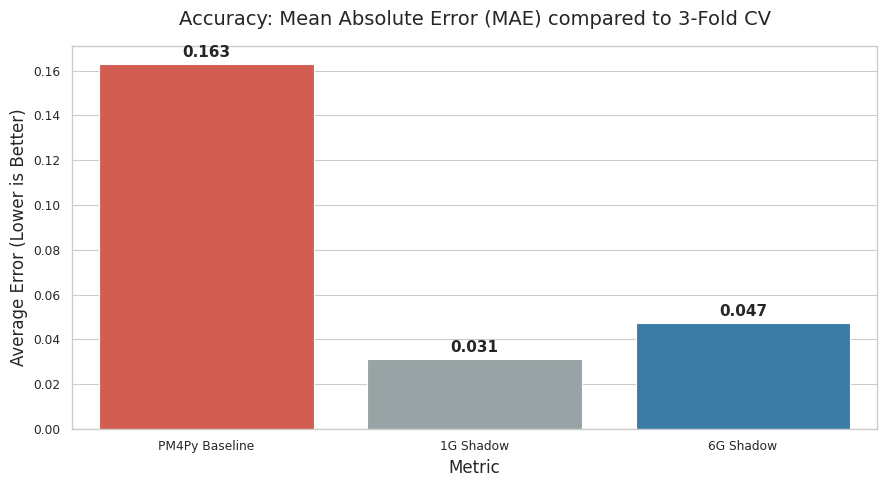

In [8]:
# ==========================================
# CELL 7: MEAN ABSOLUTE ERROR (MAE) TO GROUND TRUTH
# ==========================================
df_mae = df.copy()

# FIXED: Changed 'PM4Py_Baseline' to 'PM4Py_Gen'
df_mae['Error_PM4Py'] = abs(df_mae['PM4Py_Gen'] - df_mae['Fit_3Fold'])
df_mae['Error_1G'] = abs(df_mae['1G_Shadow'] - df_mae['Fit_3Fold'])
df_mae['Error_6G'] = abs(df_mae['6G_Shadow'] - df_mae['Fit_3Fold'])

df_melted_mae = df_mae.melt(
    id_vars=['Miner', 'Dataset'], 
    value_vars=['Error_PM4Py', 'Error_1G', 'Error_6G'], 
    var_name='Metric', 
    value_name='Absolute_Error'
)

name_map_mae = {'Error_PM4Py': 'PM4Py Baseline', 'Error_1G': '1G Shadow', 'Error_6G': '6G Shadow'}
df_melted_mae['Metric'] = df_melted_mae['Metric'].map(name_map_mae)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=df_melted_mae, x='Metric', y='Absolute_Error', estimator=np.mean, errorbar=None, palette=['#E74C3C', '#95A5A6', '#2980B9'])

plt.title('Accuracy: Mean Absolute Error (MAE) compared to 3-Fold CV', pad=15)
plt.ylabel('Average Error (Lower is Better)')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()

/tmp/ipykernel_5308/2802580407.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='Metric', y='Score', palette=['#f5b7b1', '#d5dbdb', '#a9cce3'], showfliers=False)


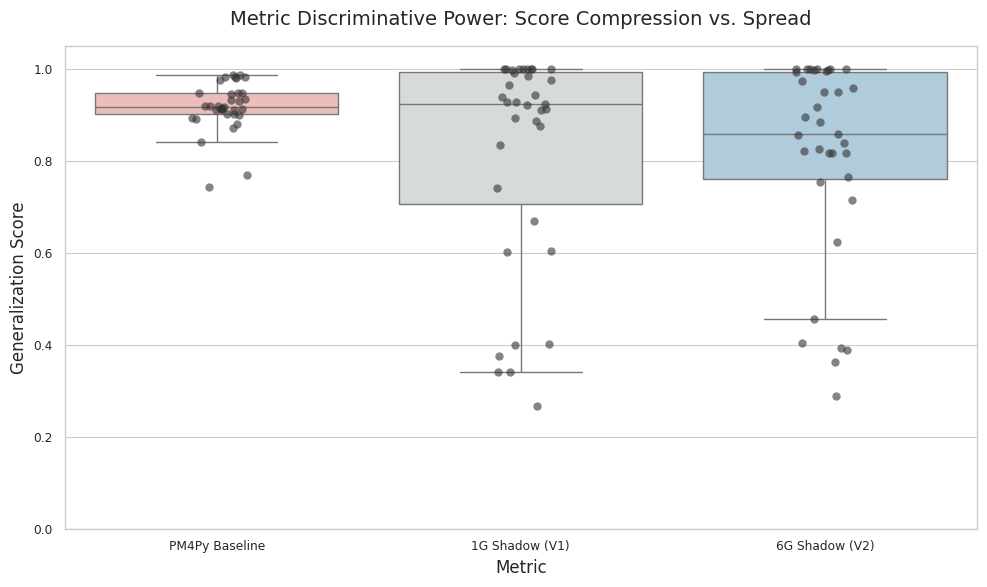

In [9]:
# ==========================================
# CELL 8: DISCRIMINATIVE POWER (BOX PLOT)
# ==========================================
# FIXED: Changed 'PM4Py_Baseline' to 'PM4Py_Gen'
df_box = df.melt(
    id_vars=['Miner', 'Dataset'], 
    value_vars=['PM4Py_Gen', '1G_Shadow', '6G_Shadow'], 
    var_name='Metric', 
    value_name='Score'
)

name_map_box = {'PM4Py_Gen': 'PM4Py Baseline', '1G_Shadow': '1G Shadow (V1)', '6G_Shadow': '6G Shadow (V2)'}
df_box['Metric'] = df_box['Metric'].map(name_map_box)

plt.figure(figsize=(10, 6))

# Create the Box Plot
sns.boxplot(data=df_box, x='Metric', y='Score', palette=['#f5b7b1', '#d5dbdb', '#a9cce3'], showfliers=False)

# Overlay a stripplot to show the actual data points
sns.stripplot(data=df_box, x='Metric', y='Score', color=".2", alpha=0.6, jitter=True, size=6)

plt.title('Metric Discriminative Power: Score Compression vs. Spread', pad=15)
plt.ylabel('Generalization Score')
plt.ylim(0, 1.05)

plt.show()

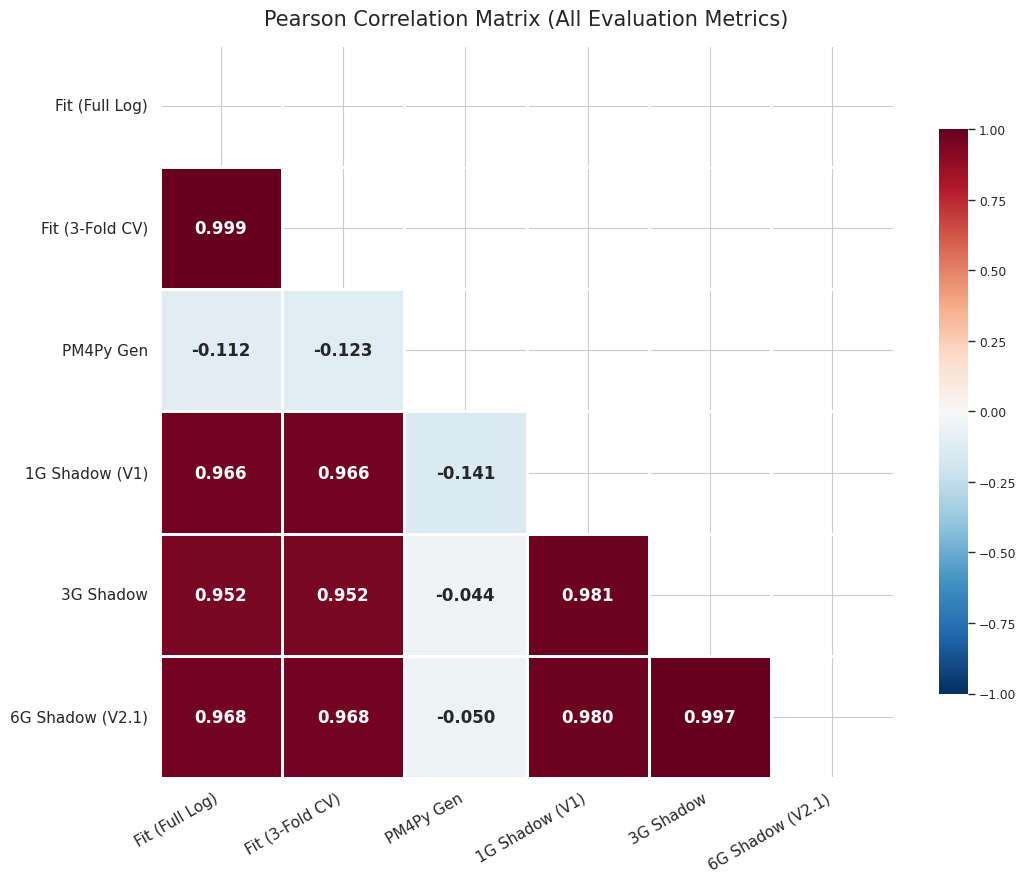

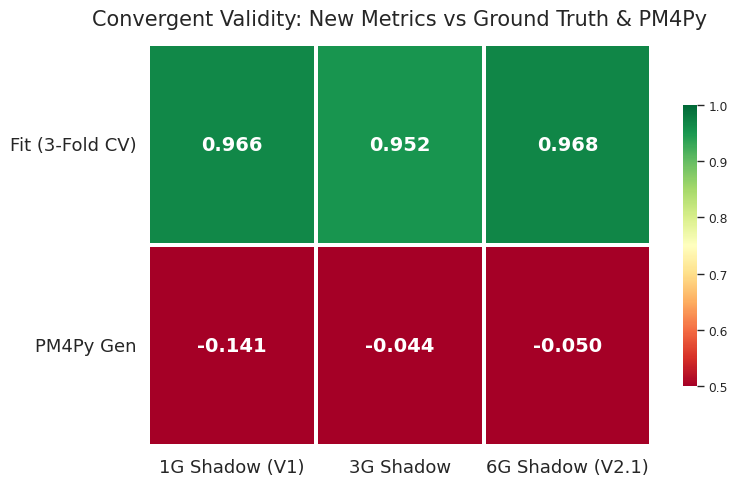

Key Correlation Insights:
------------------------------------------------------------
  6G Shadow ↔ 3-Fold CV:    r = +0.968  ✓ Strong alignment with ground truth
  PM4Py Gen  ↔ 3-Fold CV:    r = -0.123  ✗ PM4Py baseline fails to track ground truth
  6G Shadow ↔ PM4Py Gen:     r = -0.050  → Metrics capture DIFFERENT aspects of generalization

  Context Evolution (1G → 3G → 6G vs Fit_3Fold):
    1G: r=+0.966  →  3G: r=+0.952  →  6G: r=+0.968  ✓ Higher N-gram = better alignment


In [12]:
# ==========================================
# CELL 9: CORRELATION MATRIX — New Metrics vs PM4Py vs Ground Truth
# ==========================================
# Compute Pearson correlation matrix across all evaluation metrics
# This reveals: do new metrics (1G/3G/6G Shadow) capture the same signal
# as PM4Py_Gen, or do they measure something fundamentally different?

metric_cols = ['Fit_Full', 'Fit_3Fold', 'PM4Py_Gen', '1G_Shadow', '3G_Shadow', '6G_Shadow']
df_corr_matrix = df[metric_cols].corr(method='pearson')

# Clean labels for display
label_map = {
    'Fit_Full': 'Fit (Full Log)',
    'Fit_3Fold': 'Fit (3-Fold CV)',
    'PM4Py_Gen': 'PM4Py Gen',
    '1G_Shadow': '1G Shadow (V1)',
    '3G_Shadow': '3G Shadow',
    '6G_Shadow': '6G Shadow (V2.1)',
}
df_corr_matrix = df_corr_matrix.rename(index=label_map, columns=label_map)

# --- Plot 1: Full Correlation Heatmap (Large standalone) ---
fig1, ax1 = plt.subplots(figsize=(11, 9))

mask = np.triu(np.ones_like(df_corr_matrix, dtype=bool), k=0)
sns.heatmap(
    df_corr_matrix,
    mask=mask,
    annot=True, fmt='.3f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.8, cbar_kws={'shrink': 0.75},
    ax=ax1,
    annot_kws={'fontsize': 12, 'fontweight': 'bold'}
)
ax1.set_title('Pearson Correlation Matrix (All Evaluation Metrics)', fontsize=15, pad=14)
ax1.tick_params(axis='both', labelsize=11, rotation=0)
# Rotate x labels diagonally to prevent overlap
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right', fontsize=11)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=11)
fig1.tight_layout()
plt.show()

# --- Plot 2: Convergent Validity (Large standalone) ---
# Focused view: how do new metrics relate to Fit_3Fold (ground truth) and PM4Py_Gen (baseline)?
focus_rows = ['Fit (3-Fold CV)', 'PM4Py Gen']
focus_cols = ['1G Shadow (V1)', '3G Shadow', '6G Shadow (V2.1)']
df_focus = df_corr_matrix.loc[focus_rows, focus_cols]

fig2, ax2 = plt.subplots(figsize=(8, 5))
sns.heatmap(
    df_focus,
    annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.5, vmax=1.0, center=0.75,
    square=False, linewidths=1.5, cbar_kws={'shrink': 0.7},
    ax=ax2,
    annot_kws={'fontsize': 14, 'fontweight': 'bold'}
)
ax2.set_title('Convergent Validity: New Metrics vs Ground Truth & PM4Py', fontsize=15, pad=14)
ax2.set_ylabel('')
ax2.tick_params(axis='both', labelsize=13, rotation=0)
fig2.tight_layout()
plt.show()

# --- Print Key Insights ---
print("Key Correlation Insights:")
print("-" * 60)
# 6G Shadow vs Fit_3Fold
corr_6g = df['6G_Shadow'].corr(df['Fit_3Fold'])
print(f"  6G Shadow ↔ 3-Fold CV:    r = {corr_6g:+.3f}  {'✓ Strong alignment with ground truth' if corr_6g > 0.8 else '⚠ Moderate' if corr_6g > 0.5 else '✗ Weak'}")

# PM4Py_Gen vs Fit_3Fold
corr_pm4py = df['PM4Py_Gen'].corr(df['Fit_3Fold'])
print(f"  PM4Py Gen  ↔ 3-Fold CV:    r = {corr_pm4py:+.3f}  {'✗ PM4Py baseline fails to track ground truth' if corr_pm4py < 0.3 else '⚠ Weak correlation'}")

# 6G Shadow vs PM4Py_Gen (divergence = new information)
corr_div = df['6G_Shadow'].corr(df['PM4Py_Gen'])
print(f"  6G Shadow ↔ PM4Py Gen:     r = {corr_div:+.3f}  {'→ Metrics capture DIFFERENT aspects of generalization' if abs(corr_div) < 0.5 else '→ Strong overlap — metrics may be redundant'}")

# Context evolution: does higher N-gram improve ground truth alignment?
corr_1g = df['1G_Shadow'].corr(df['Fit_3Fold'])
corr_3g = df['3G_Shadow'].corr(df['Fit_3Fold'])
print(f"\n  Context Evolution (1G → 3G → 6G vs Fit_3Fold):")
print(f"    1G: r={corr_1g:+.3f}  →  3G: r={corr_3g:+.3f}  →  6G: r={corr_6g:+.3f}  {'✓ Higher N-gram = better alignment' if corr_6g > corr_1g else '⚠ No improvement'}")